<!-- [![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/VectorInstitute/interpretability/blob/main/implementations/Post-hoc/SHAP/shap-nn-jupyter.ipynb)
 -->
# SHAP for Neural Network Models

## **1. Introduction**

SHAP is model-agnostic and can be used to explain other black box models as well, for example, neural networks.
The shap module in python has something called KernelExplainer which can be used for NNs.

Let's illustrate this using a [Credit Card Defaulter dataset from Taiwan](https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients)

The dataset has the following 23 variables as explanatory variables:
| Variable | Description |
|----------|------------|
| LIMIT_BAL  | Amount of the given credit (NT dollar): includes both individual consumer credit and family (supplementary) credit. |
| SEX  | Gender (1 = male; 2 = female). |
| EDUCATION  | Education (1 = graduate school; 2 = university; 3 = high school; 4 = others). |
| MARRIAGE  | Marital status (1 = married; 2 = single; 3 = others). |
| AGE  | Age (years). |
| PAY_0  | Repayment status in September 2005 (-1 = pay duly; 1 = delay for 1 month; 2 = delay for 2 months; ...; 8 = delay for 8 months; 9 = delay for 9+ months). |
|  PAY_2 | Repayment status in August 2005. |
| PAY_3  | Repayment status in July 2005. |
| PAY_4  | Repayment status in June 2005. |
| PAY_5 | Repayment status in May 2005. |
| PAY_6 | Repayment status in April 2005. |
| BILL_AMT1 | Amount of bill statement (NT dollar) in September 2005. |
| BILL_AMT2 | Amount of bill statement (NT dollar) in August 2005. |
| BILL_AMT3 | Amount of bill statement (NT dollar) in July 2005. |
| BILL_AMT4 | Amount of bill statement (NT dollar) in June 2005. |
| BILL_AMT5 | Amount of bill statement (NT dollar) in May 2005. |
| BILL_AMT6 | Amount of bill statement (NT dollar) in April 2005. |
| PAY_AMT1 | Amount of previous payment (NT dollar) in September 2005. |
| PAY_AMT2 | Amount of previous payment (NT dollar) in August 2005. |
| PAY_AMT3 | Amount of previous payment (NT dollar) in July 2005. |
| PAY_AMT4 | Amount of previous payment (NT dollar) in June 2005. |
| PAY_AMT5 | Amount of previous payment (NT dollar) in May 2005. |
| PAY_AMT6 | Amount of previous payment (NT dollar) in April 2005. |

## **2. Import the necessary libraries**

In [2]:
import numpy as np
import pandas as pd
import shap
import torch
from sklearn.metrics import RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn, optim
from torch.utils.data import DataLoader, Dataset


np.random.seed(1)

## **3. Loading the dataset**

In [2]:
!curl -o data/clients.zip https://archive.ics.uci.edu/static/public/350/default+of+credit+card+clients.zip
!unzip -o data/clients.zip -d data
!rm data/clients.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 5409k    0 5409k    0     0  6287k      0 --:--:-- --:--:-- --:--:-- 6282k
Archive:  data/clients.zip
 extracting: data/default of credit card clients.xls  


In [3]:
# Load the data
data = pd.read_excel(
    "data/default of credit card clients.xls",
    header=1,
)
data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


## **4. Create a PyTorch dataset**
Create a dataset class inherited from PyTorch Dataset to be input for model training.

In [4]:
# Load dataset
X = data.drop(["default payment next month", "ID"], axis=1)
y = data["default payment next month"]

# Scale the data
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
y_train = y_train.values  # Convert pandas series to NumPy array
y_test = y_test.values


# Create a PyTorch Dataset
class CreditDataset(Dataset):
    """PyTorch Dataset for Credit data."""

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)  # Reshape y to be column vector

    def __len__(self):
        """Return dataset length."""
        return len(self.X)

    def __getitem__(self, idx):
        """Get item at index."""
        return self.X[idx], self.y[idx]


# Create DataLoaders for batching
batch_size = 64
train_dataset = CreditDataset(X_train, y_train)
test_dataset = CreditDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## **5. Train a 3-layer MLP using PyTorch**
Let's train a simple 3-layer MLP to predict credit card defaults.

Epoch [10/125], Loss: 0.4290
Epoch [20/125], Loss: 0.4222
Epoch [30/125], Loss: 0.4176
Epoch [40/125], Loss: 0.4119
Epoch [50/125], Loss: 0.4091
Epoch [60/125], Loss: 0.4062
Epoch [70/125], Loss: 0.4040
Epoch [80/125], Loss: 0.4004
Epoch [90/125], Loss: 0.3991
Epoch [100/125], Loss: 0.3972
Epoch [110/125], Loss: 0.3932
Epoch [120/125], Loss: 0.3916
Accuracy: 0.8083
ROC AUC Score: 0.7569


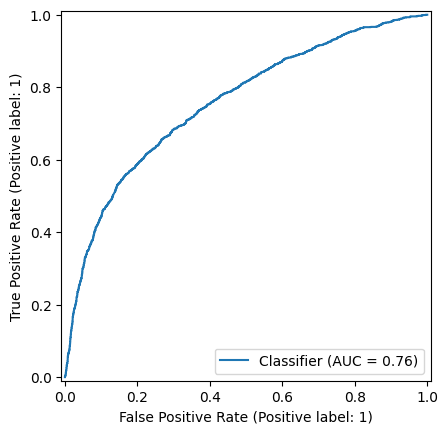

In [5]:
# Define the model
model = nn.Sequential(
    nn.Linear(X_train.shape[1], 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(32, 1),
    nn.Sigmoid(),
)

# Loss function and optimizer
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model in batches
num_epochs = 125
for epoch in range(num_epochs):
    model.train()  # Set model to training mode
    running_loss = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Print average loss every 10 epochs
    if (epoch + 1) % 10 == 0:
        avg_loss = running_loss / len(train_loader)
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}")

# Evaluate the model
model.eval()  # Set model to evaluation mode
y_pred_probs = []
y_true = []

with torch.no_grad():
    for batch_x, batch_y in test_loader:
        outputs = model(batch_x)
        y_pred_probs.extend(outputs.numpy())  # Store predictions
        y_true.extend(batch_y.numpy())  # Store true labels

# Convert predictions to NumPy array
y_pred_probs = np.array(y_pred_probs).flatten()
y_true = np.array(y_true).flatten()

# Compute accuracy
accuracy = ((y_pred_probs > 0.5) == y_true).mean()
print(f"Accuracy: {accuracy:.4f}")

# Compute ROC AUC score
roc_auc = roc_auc_score(y_true, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

# Plot ROC curve
RocCurveDisplay.from_predictions(y_true, y_pred_probs)

## **6. Use SHAP to explain Neural network predictions**

Using 200 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/50 [00:00<?, ?it/s]

X_test_sample shape: (50, 23)
SHAP values shape: (50, 23, 1)
Updated SHAP values shape: (50, 23)


/tmp/ipykernel_5593/1316485072.py:40: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample, feature_names=data.columns[1:-1])


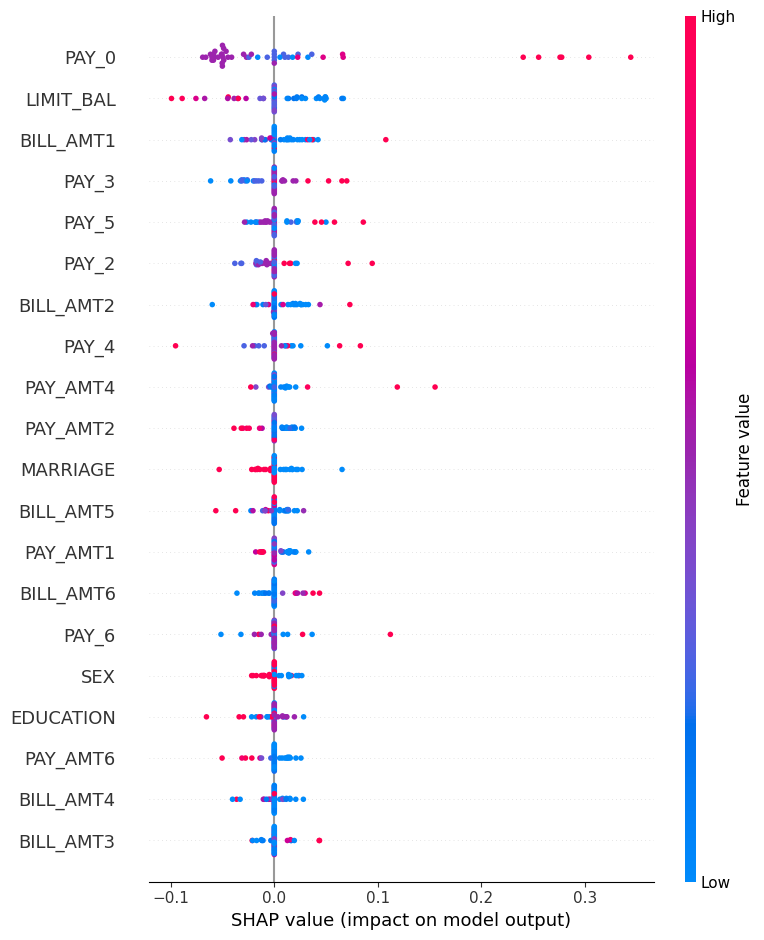

In [6]:
# Use existing NumPy arrays
X_train_np = X_train
X_test_np = X_test

# Reduce background dataset for SHAP (using 200 samples instead of full training set)
background = shap.kmeans(X_train_np, 200)


# Wrapper function for PyTorch model inference
def model_wrapper(data):
    """Model wrapper for SHAP."""
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32)
        return model(data_tensor).detach().numpy()
        # Should be (n_samples, n_classes)


# Use KernelExplainer with reduced background
explainer = shap.KernelExplainer(model_wrapper, background)

# Explain only a small subset of the test set (e.g., 50 samples)
X_test_sample = X_test_np[:50]

# Compute SHAP values
shap_values = explainer.shap_values(X_test_sample)

print("X_test_sample shape:", X_test_sample.shape)  # Should be (n_samples, n_features)
print("SHAP values shape:", np.array(shap_values).shape)  # Should match (n_samples, n_features)

# Remove extra dimension if shap_values is (50, 23, 1)
shap_values = np.array(shap_values)  # Convert to NumPy array
if shap_values.shape[-1] == 1:
    shap_values = shap_values.squeeze(-1)  # Remove last dimension

# Ensure correct shape
print("Updated SHAP values shape:", shap_values.shape)  # Should be (50, 23)


# Generate SHAP summary plot
shap.summary_plot(shap_values, X_test_sample, feature_names=data.columns[1:-1])

In [9]:
import json

def shap_to_structured_explanation(sample_idx, shap_values, X_test_sample, model_predictions, baseline_value, feature_names, top_k=5):
    """
    Convert SHAP values to a clean, structured explanation format.
    
    Args:
        sample_idx: Index of the sample to explain
        shap_values: Array of SHAP values (n_samples, n_features)
        X_test_sample: Feature values (n_samples, n_features)
        model_predictions: Model predictions (probabilities)
        baseline_value: Baseline/expected model output
        feature_names: List of feature names
        top_k: Number of top positive/negative factors to include
    
    Returns:
        Dictionary with structured explanation
    """
    
    # Get SHAP values and features for this sample
    sample_shap = shap_values[sample_idx]
    sample_features = X_test_sample[sample_idx]
    prediction_prob = model_predictions[sample_idx]
    
    # Determine label (threshold at 0.5)
    label = "Default" if prediction_prob > 0.5 else "No Default"
    
    # Create feature-SHAP pairs
    feature_impacts = []
    for i, (feature_name, shap_val, feature_val) in enumerate(zip(feature_names, sample_shap, sample_features)):
        feature_impacts.append({
            "feature": feature_name,
            "value": float(feature_val),
            "impact": float(shap_val),
            "index": i
        })
    
    # Separate positive and negative impacts
    positive_factors = sorted([f for f in feature_impacts if f["impact"] > 0], 
                             key=lambda x: x["impact"], reverse=True)[:top_k]
    negative_factors = sorted([f for f in feature_impacts if f["impact"] < 0], 
                             key=lambda x: x["impact"])[:top_k]
    
    # Build structured output
    explanation = {
        "prediction": {
            "label": label,
            "probability": round(float(prediction_prob), 4)
        },
        "baseline": round(float(baseline_value), 4),
        "top_positive_factors": [
            {
                "feature": f["feature"],
                "value": round(f["value"], 2),
                "impact": round(f["impact"], 4)
            }
            for f in positive_factors
        ],
        "top_negative_factors": [
            {
                "feature": f["feature"],
                "value": round(f["value"], 2),
                "impact": round(f["impact"], 4)
            }
            for f in negative_factors
        ]
    }
    
    return explanation


# Get baseline value (expected model output from background data)
background_data = background.data if hasattr(background, 'data') else np.array(background)
baseline_value = model_wrapper(background_data).mean()

# Get model predictions for test samples
model_predictions = model_wrapper(X_test_sample).flatten()

# Get feature names (excluding ID and target)
feature_names = list(data.columns[1:-1])

# Example: Generate explanations for first 3 samples
print("=" * 80)
print("STRUCTURED SHAP EXPLANATIONS")
print("=" * 80)

for i in range(3):
    explanation = shap_to_structured_explanation(
        sample_idx=i,
        shap_values=shap_values,
        X_test_sample=X_test_sample,
        model_predictions=model_predictions,
        baseline_value=baseline_value,
        feature_names=feature_names,
        top_k=5
    )
    
    print(f"\n📊 Sample {i+1}:")
    print(json.dumps(explanation, indent=2))
    print("-" * 80)

STRUCTURED SHAP EXPLANATIONS

📊 Sample 1:
{
  "prediction": {
    "label": "No Default",
    "probability": 0.1868
  },
  "baseline": 0.173,
  "top_positive_factors": [
    {
      "feature": "LIMIT_BAL",
      "value": -1.06,
      "impact": 0.05
    },
    {
      "feature": "BILL_AMT1",
      "value": -0.58,
      "impact": 0.0185
    },
    {
      "feature": "PAY_AMT2",
      "value": -0.17,
      "impact": 0.0158
    },
    {
      "feature": "PAY_AMT1",
      "value": -0.25,
      "impact": 0.0131
    },
    {
      "feature": "BILL_AMT5",
      "value": -0.44,
      "impact": 0.0109
    }
  ],
  "top_negative_factors": [
    {
      "feature": "PAY_0",
      "value": 0.01,
      "impact": -0.0573
    },
    {
      "feature": "AGE",
      "value": -1.14,
      "impact": -0.0216
    },
    {
      "feature": "BILL_AMT3",
      "value": -0.51,
      "impact": -0.0125
    },
    {
      "feature": "BILL_AMT2",
      "value": -0.55,
      "impact": -0.0109
    }
  ]
}
-------------

In [10]:
import os
from pathlib import Path

# Create output directory for JSON files
output_dir = Path("shap_explanations")
output_dir.mkdir(exist_ok=True)

# Generate and save explanations for ALL test samples
all_explanations = []

print("=" * 80)
print("SAVING SHAP EXPLANATIONS TO JSON FILES")
print("=" * 80)

for i in range(len(X_test_sample)):
    explanation = shap_to_structured_explanation(
        sample_idx=i,
        shap_values=shap_values,
        X_test_sample=X_test_sample,
        model_predictions=model_predictions,
        baseline_value=baseline_value,
        feature_names=feature_names,
        top_k=5
    )
    
    # Add sample ID for reference
    explanation["sample_id"] = i
    all_explanations.append(explanation)
    
    # Save individual JSON file for each sample
    file_path = output_dir / f"sample_{i:03d}.json"
    with open(file_path, "w") as f:
        json.dump(explanation, f, indent=2)
    
    if (i + 1) % 10 == 0:
        print(f"✓ Saved {i + 1} explanations...")

# Save consolidated file with all explanations
consolidated_path = output_dir / "all_explanations.json"
with open(consolidated_path, "w") as f:
    json.dump(all_explanations, f, indent=2)

# Create a summary file with metadata
summary = {
    "total_samples": len(X_test_sample),
    "num_features": X_test_sample.shape[1],
    "feature_names": feature_names,
    "baseline_probability": float(baseline_value),
    "model_accuracy": float(accuracy),
    "model_roc_auc": float(roc_auc),
    "output_directory": str(output_dir),
    "files_created": {
        "individual_files": f"sample_000.json through sample_{len(X_test_sample)-1:03d}.json",
        "consolidated_file": "all_explanations.json",
        "summary_file": "summary.json"
    }
}

summary_path = output_dir / "summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("\n" + "=" * 80)
print("✅ ALL FILES SAVED SUCCESSFULLY!")
print("=" * 80)
print(f"\n📁 Output Directory: {output_dir.resolve()}")
print(f"📊 Total Samples: {len(X_test_sample)}")
print(f"\n📄 Files Created:")
print(f"   • Individual files: sample_000.json → sample_{len(X_test_sample)-1:03d}.json")
print(f"   • Consolidated file: all_explanations.json")
print(f"   • Summary file: summary.json")
print("\n💡 Load explanations in Python:")
print("   with open('shap_explanations/all_explanations.json', 'r') as f:")
print("       explanations = json.load(f)")


SAVING SHAP EXPLANATIONS TO JSON FILES
✓ Saved 10 explanations...
✓ Saved 20 explanations...
✓ Saved 30 explanations...
✓ Saved 40 explanations...
✓ Saved 50 explanations...

✅ ALL FILES SAVED SUCCESSFULLY!

📁 Output Directory: /home/coder/interpretability-llms-agents/implementations/xai_refresher/shap_explanations
📊 Total Samples: 50

📄 Files Created:
   • Individual files: sample_000.json → sample_049.json
   • Consolidated file: all_explanations.json
   • Summary file: summary.json

💡 Load explanations in Python:
   with open('shap_explanations/all_explanations.json', 'r') as f:
       explanations = json.load(f)


In [12]:
def explain_prediction_in_plain_language(explanation, baseline_context="the average customer"):
    """
    Convert SHAP explanation to plain language for financial risk analysts.
    
    Args:
        explanation: Dict with prediction, baseline, positive/negative factors
        baseline_context: Description of baseline for context
    
    Returns:
        String with narrative explanation
    """
    
    pred = explanation["prediction"]
    label = pred["label"]
    prob = pred["probability"]
    baseline = explanation["baseline"]
    pos_factors = explanation["top_positive_factors"]
    neg_factors = explanation["top_negative_factors"]
    
    # Build narrative
    lines = []
    
    # Opening statement about prediction
    if label == "Default":
        risk_level = "elevated" if prob > 0.7 else "moderate"
        lines.append(
            f"This customer has a {risk_level} risk of default with a {prob*100:.1f}% probability. "
            f"This is {'higher' if prob > baseline else 'lower'} than {baseline_context} ({baseline*100:.1f}%)."
        )
    else:
        lines.append(
            f"This customer is predicted to remain current on their payments, with only a {prob*100:.1f}% default risk. "
            f"This is {'better' if prob < baseline else 'worse'} than {baseline_context} ({baseline*100:.1f}%)."
        )
    
    # Explain positive factors (risk drivers)
    if pos_factors:
        risk_drivers = []
        for factor in pos_factors:
            feat = factor["feature"]
            impact = abs(factor["impact"])
            
            # Translate feature names to plain language
            feature_explanations = {
                "PAY_0": "recent payment delays",
                "PAY_2": "payment history",
                "PAY_3": "payment history", 
                "PAY_4": "payment history",
                "PAY_5": "payment history",
                "PAY_6": "payment history",
                "BILL_AMT1": "bill amounts",
                "BILL_AMT2": "bill amounts",
                "BILL_AMT3": "bill amounts",
                "BILL_AMT4": "bill amounts",
                "BILL_AMT5": "bill amounts",
                "BILL_AMT6": "bill amounts",
                "LIMIT_BAL": "credit limit",
                "PAY_AMT1": "payment amounts",
                "PAY_AMT2": "payment amounts",
                "PAY_AMT3": "payment amounts",
                "PAY_AMT4": "payment amounts",
                "PAY_AMT5": "payment amounts",
                "PAY_AMT6": "payment amounts",
            }
            plain_feat = feature_explanations.get(feat, feat)
            risk_drivers.append(plain_feat)
        
        risk_drivers = list(dict.fromkeys(risk_drivers))  # Remove duplicates while preserving order
        risk_text = " and ".join(risk_drivers) if len(risk_drivers) > 1 else risk_drivers[0]
        lines.append(f"The main risk factors are {risk_text}.")
    
    # Explain negative factors (protective factors)
    if neg_factors:
        protective_factors = []
        for factor in neg_factors:
            feat = factor["feature"]
            
            feature_explanations = {
                "PAY_0": "good recent payment status",
                "LIMIT_BAL": "higher credit limit",
                "PAY_AMT1": "strong payment amounts",
                "PAY_AMT2": "strong payment amounts",
                "BILL_AMT1": "lower bill amounts",
                "AGE": "customer age",
                "EDUCATION": "education level",
            }
            plain_feat = feature_explanations.get(feat, feat)
            protective_factors.append(plain_feat)
        
        protective_factors = list(dict.fromkeys(protective_factors))
        protective_text = " and ".join(protective_factors) if len(protective_factors) > 1 else protective_factors[0]
        lines.append(f"However, {protective_text} work in their favor.")
    
    # Final assessment
    if label == "Default":
        lines.append("Recommend closer monitoring or risk mitigation measures.")
    else:
        lines.append("This customer appears to be a reliable borrower.")
    
    return " ".join(lines)


# Generate plain language explanations for all samples
print("=" * 80)
print("FINANCIAL ANALYST SUMMARIES")
print("=" * 80)

all_narratives = []

for i in range(len(X_test_sample)):
    # Load explanation from our structured format
    explanation = shap_to_structured_explanation(
        sample_idx=i,
        shap_values=shap_values,
        X_test_sample=X_test_sample,
        model_predictions=model_predictions,
        baseline_value=baseline_value,
        feature_names=feature_names,
        top_k=5
    )
    
    # Generate plain language explanation
    narrative = explain_prediction_in_plain_language(explanation)
    
    # Store with ID for later reference
    narrative_record = {
        "sample_id": i,
        "narrative": narrative,
        "prediction": explanation["prediction"],
        "baseline": explanation["baseline"]
    }
    all_narratives.append(narrative_record)
    
    # Display first 5 examples
    if i < 5:
        print(f"\n📋 Sample {i}:")
        print(narrative)
        print()

# Save all narratives to JSON
narratives_path = output_dir / "plain_language_explanations.json"
with open(narratives_path, "w") as f:
    json.dump(all_narratives, f, indent=2)

print("=" * 80)
print(f"✅ Saved {len(all_narratives)} plain language explanations to 'plain_language_explanations.json'")
print("=" * 80)

FINANCIAL ANALYST SUMMARIES

📋 Sample 0:
This customer is predicted to remain current on their payments, with only a 18.7% default risk. This is worse than the average customer (17.3%). The main risk factors are credit limit and bill amounts and payment amounts. However, good recent payment status and customer age and BILL_AMT3 and BILL_AMT2 work in their favor. This customer appears to be a reliable borrower.


📋 Sample 1:
This customer is predicted to remain current on their payments, with only a 7.5% default risk. This is better than the average customer (17.3%). However, good recent payment status and MARRIAGE and BILL_AMT5 and PAY_2 and PAY_5 work in their favor. This customer appears to be a reliable borrower.


📋 Sample 2:
This customer is predicted to remain current on their payments, with only a 12.8% default risk. This is better than the average customer (17.3%). The main risk factors are credit limit and bill amounts and MARRIAGE. However, good recent payment status and BILL

In [13]:
def create_executive_summary(explanation, sample_num=None):
    """
    Create a concise executive summary of prediction with relative importance.
    
    Args:
        explanation: Dict with prediction, baseline, positive/negative factors
        sample_num: Optional sample number for reference
    
    Returns:
        Formatted executive summary string
    """
    
    pred = explanation["prediction"]
    label = pred["label"]
    prob = pred["probability"]
    baseline = explanation["baseline"]
    pos_factors = explanation["top_positive_factors"]
    neg_factors = explanation["top_negative_factors"]
    
    # Combine all factors and rank by absolute impact
    all_factors = []
    for factor in pos_factors:
        all_factors.append({
            "feature": factor["feature"],
            "impact": factor["impact"],
            "direction": "Risk ↑"
        })
    for factor in neg_factors:
        all_factors.append({
            "feature": factor["feature"],
            "impact": abs(factor["impact"]),
            "direction": "Risk ↓"
        })
    
    # Sort by absolute impact
    all_factors.sort(key=lambda x: x["impact"], reverse=True)
    
    # Calculate total impact magnitude
    total_impact = sum(f["impact"] for f in all_factors)
    
    # Build summary
    summary = []
    summary.append("=" * 70)
    if sample_num is not None:
        summary.append(f"CUSTOMER #{sample_num} - CREDIT DEFAULT RISK ASSESSMENT")
    else:
        summary.append("CREDIT DEFAULT RISK ASSESSMENT")
    summary.append("=" * 70)
    
    # Prediction section
    summary.append(f"\n📊 PREDICTION: {label}")
    summary.append(f"   Default Probability: {prob*100:.1f}%")
    summary.append(f"   Baseline (Avg Customer): {baseline*100:.1f}%")
    summary.append(f"   Relative Risk: {'ABOVE' if prob > baseline else 'BELOW'} average " +
                   f"({'+' if prob > baseline else ''}{(prob-baseline)*100:.1f}%)")
    
    # Key drivers section
    summary.append(f"\n🔑 KEY DRIVERS (Ranked by Strength):")
    for i, factor in enumerate(all_factors[:5], 1):
        pct_of_total = (factor["impact"] / total_impact * 100) if total_impact > 0 else 0
        impact_bar = "█" * int(pct_of_total / 5)  # Visual bar (5% per block)
        summary.append(
            f"   {i}. {factor['feature']:<12} {factor['direction']:<10} "
            f"Impact: {factor['impact']:+.4f} ({pct_of_total:>5.1f}%) {impact_bar}"
        )
    
    # Risk classification
    summary.append(f"\n⚠️  RISK CLASSIFICATION:")
    if label == "Default":
        if prob > 0.7:
            summary.append("   HIGH RISK - Recommend credit review or enhanced monitoring")
        else:
            summary.append("   MODERATE RISK - Standard monitoring recommended")
    else:
        if prob < 0.1:
            summary.append("   LOW RISK - Strong credit profile")
        else:
            summary.append("   ACCEPTABLE RISK - Monitor as part of routine review")
    
    summary.append("\n" + "=" * 70)
    
    return "\n".join(summary)


# Generate executive summaries for all samples
print("\n\n")
print("█" * 70)
print("█" + " " * 68 + "█")
print("█" + "  EXECUTIVE SUMMARY REPORTS - CREDIT DEFAULT RISK".center(68) + "█")
print("█" + " " * 68 + "█")
print("█" * 70)

all_executive_summaries = []

for i in range(len(X_test_sample)):
    explanation = shap_to_structured_explanation(
        sample_idx=i,
        shap_values=shap_values,
        X_test_sample=X_test_sample,
        model_predictions=model_predictions,
        baseline_value=baseline_value,
        feature_names=feature_names,
        top_k=5
    )
    
    summary_text = create_executive_summary(explanation, sample_num=i+1)
    all_executive_summaries.append({
        "sample_id": i,
        "summary": summary_text,
        "prediction": explanation["prediction"],
        "baseline": explanation["baseline"]
    })
    
    # Display first 3 examples
    if i < 3:
        print(summary_text)

# Save executive summaries
exec_summary_path = output_dir / "executive_summaries.json"
with open(exec_summary_path, "w") as f:
    json.dump(all_executive_summaries, f, indent=2)

print("\n" + "█" * 70)
print(f"✅ Generated {len(all_executive_summaries)} executive summaries")
print(f"📁 Saved to: shap_explanations/executive_summaries.json")
print("█" * 70)




██████████████████████████████████████████████████████████████████████
█                                                                    █
█           EXECUTIVE SUMMARY REPORTS - CREDIT DEFAULT RISK          █
█                                                                    █
██████████████████████████████████████████████████████████████████████
CUSTOMER #1 - CREDIT DEFAULT RISK ASSESSMENT

📊 PREDICTION: No Default
   Default Probability: 18.7%
   Baseline (Avg Customer): 17.3%
   Relative Risk: ABOVE average (+1.4%)

🔑 KEY DRIVERS (Ranked by Strength):
   1. PAY_0        Risk ↓     Impact: +0.0573 ( 27.2%) █████
   2. LIMIT_BAL    Risk ↑     Impact: +0.0500 ( 23.7%) ████
   3. AGE          Risk ↓     Impact: +0.0216 ( 10.3%) ██
   4. BILL_AMT1    Risk ↑     Impact: +0.0185 (  8.8%) █
   5. PAY_AMT2     Risk ↑     Impact: +0.0158 (  7.5%) █

⚠️  RISK CLASSIFICATION:
   ACCEPTABLE RISK - Monitor as part of routine review

CUSTOMER #2 - CREDIT DEFAULT RISK ASSESSMENT

📊 PREDICT

In [14]:
def create_feature_narrative_explanation(explanation, sample_num=None):
    """
    Create detailed narrative explanation of each key feature (few-shot style).
    
    Args:
        explanation: Dict with prediction, baseline, positive/negative factors
        sample_num: Optional sample number for reference
    
    Returns:
        Formatted narrative explanation
    """
    
    # Feature context dictionary
    feature_context = {
        "PAY_0": {
            "full_name": "Repayment Status - Most Recent Month",
            "scale": "(-1 = paid on time, 1-9 = months of delay)",
            "positive": "More delays strongly increase default risk",
            "negative": "On-time payment reduces default risk"
        },
        "PAY_2": {"full_name": "Repayment Status - August", "scale": "(months of delay)"},
        "PAY_3": {"full_name": "Repayment Status - July", "scale": "(months of delay)"},
        "PAY_4": {"full_name": "Repayment Status - June", "scale": "(months of delay)"},
        "PAY_5": {"full_name": "Repayment Status - May", "scale": "(months of delay)"},
        "PAY_6": {"full_name": "Repayment Status - April", "scale": "(months of delay)"},
        "LIMIT_BAL": {
            "full_name": "Credit Limit Amount",
            "scale": "(NT dollars)",
            "positive": "Lower credit limits associated with higher default risk",
            "negative": "Higher credit limits reduce default risk"
        },
        "BILL_AMT1": {
            "full_name": "Bill Amount - September",
            "scale": "(NT dollars)",
            "note": "Higher bills have mixed impact depending on context"
        },
        "BILL_AMT2": {"full_name": "Bill Amount - August", "scale": "(NT dollars)"},
        "BILL_AMT3": {"full_name": "Bill Amount - July", "scale": "(NT dollars)"},
        "BILL_AMT4": {"full_name": "Bill Amount - June", "scale": "(NT dollars)"},
        "BILL_AMT5": {"full_name": "Bill Amount - May", "scale": "(NT dollars)"},
        "BILL_AMT6": {"full_name": "Bill Amount - April", "scale": "(NT dollars)"},
        "PAY_AMT1": {
            "full_name": "Payment Amount - September",
            "scale": "(NT dollars)",
            "positive": "Higher payment amounts increase default risk",
            "negative": "Lower payment amounts reduce risk"
        },
        "PAY_AMT2": {"full_name": "Payment Amount - August", "scale": "(NT dollars)"},
        "PAY_AMT3": {"full_name": "Payment Amount - July", "scale": "(NT dollars)"},
        "PAY_AMT4": {"full_name": "Payment Amount - June", "scale": "(NT dollars)"},
        "PAY_AMT5": {"full_name": "Payment Amount - May", "scale": "(NT dollars)"},
        "PAY_AMT6": {"full_name": "Payment Amount - April", "scale": "(NT dollars)"},
        "AGE": {
            "full_name": "Customer Age",
            "scale": "(years)",
            "note": "Demographics have weaker predictive power"
        },
        "SEX": {"full_name": "Gender", "scale": "(1=Male, 2=Female)"},
        "EDUCATION": {"full_name": "Education Level", "scale": "(1=Graduate, 2=University, 3=HS, 4=Other)"},
        "MARRIAGE": {"full_name": "Marital Status", "scale": "(1=Married, 2=Single, 3=Other)"}
    }
    
    pred = explanation["prediction"]
    label = pred["label"]
    prob = pred["probability"]
    baseline = explanation["baseline"]
    pos_factors = explanation["top_positive_factors"]
    neg_factors = explanation["top_negative_factors"]
    
    # Build narrative
    lines = []
    lines.append("=" * 80)
    if sample_num is not None:
        lines.append(f"DETAILED FEATURE ANALYSIS - CUSTOMER #{sample_num}")
    else:
        lines.append("DETAILED FEATURE ANALYSIS")
    lines.append("=" * 80)
    
    # Overall prediction
    lines.append(f"\nPrediction: {label} ({prob*100:.1f}% default probability)")
    lines.append(f"Baseline: {baseline*100:.1f}% (average customer)\n")
    
    # Combine factors for detailed analysis
    all_factors = []
    for factor in pos_factors:
        all_factors.append({
            "feature": factor["feature"],
            "impact": factor["impact"],
            "value": factor["value"],
            "direction": "increases"
        })
    for factor in neg_factors:
        all_factors.append({
            "feature": factor["feature"],
            "impact": abs(factor["impact"]),
            "value": factor["value"],
            "direction": "decreases"
        })
    
    # Sort by impact
    all_factors.sort(key=lambda x: x["impact"], reverse=True)
    
    # Generate narrative for each factor
    lines.append("KEY FACTORS INFLUENCING THIS PREDICTION:\n")
    
    for rank, factor in enumerate(all_factors[:5], 1):
        feat_name = factor["feature"]
        impact = factor["impact"]
        direction = factor["direction"]
        value = factor["value"]
        
        context = feature_context.get(feat_name, {})
        full_name = context.get("full_name", feat_name)
        scale = context.get("scale", "")
        
        lines.append(f"{rank}. {feat_name} ({full_name})")
        lines.append(f"   • Current Value: {value:.2f} {scale}")
        lines.append(f"   • Impact: {impact:+.4f} ({direction} default risk by {impact*100:.2f}%)")
        
        if direction == "increases" and context.get("positive"):
            lines.append(f"   • Interpretation: {context['positive']}")
        elif direction == "decreases" and context.get("negative"):
            lines.append(f"   • Interpretation: {context['negative']}")
        elif context.get("note"):
            lines.append(f"   • Note: {context['note']}")
        
        lines.append("")
    
    lines.append("=" * 80)
    
    return "\n".join(lines)


# Generate detailed feature narratives for all samples
print("\n")
print("╔" + "═" * 78 + "╗")
print("║" + "EXECUTIVE FEATURE NARRATIVES - DETAILED RISK FACTOR ANALYSIS".center(78) + "║")
print("╚" + "═" * 78 + "╝")

all_feature_narratives = []

for i in range(len(X_test_sample)):
    explanation = shap_to_structured_explanation(
        sample_idx=i,
        shap_values=shap_values,
        X_test_sample=X_test_sample,
        model_predictions=model_predictions,
        baseline_value=baseline_value,
        feature_names=feature_names,
        top_k=5
    )
    
    narrative = create_feature_narrative_explanation(explanation, sample_num=i+1)
    all_feature_narratives.append({
        "sample_id": i,
        "narrative": narrative,
        "prediction": explanation["prediction"]
    })
    
    # Display first 2 examples
    if i < 2:
        print(narrative)

# Save feature narratives
feature_narrative_path = output_dir / "feature_narratives.json"
with open(feature_narrative_path, "w") as f:
    json.dump(all_feature_narratives, f, indent=2)

print("\n" + "╔" + "═" * 78 + "╗")
print("║" + f"✅ Generated {len(all_feature_narratives)} feature narratives".center(78) + "║")
print("║" + "📁 Saved to: shap_explanations/feature_narratives.json".center(78) + "║")
print("╚" + "═" * 78 + "╝")



╔══════════════════════════════════════════════════════════════════════════════╗
║         EXECUTIVE FEATURE NARRATIVES - DETAILED RISK FACTOR ANALYSIS         ║
╚══════════════════════════════════════════════════════════════════════════════╝
DETAILED FEATURE ANALYSIS - CUSTOMER #1

Prediction: No Default (18.7% default probability)
Baseline: 17.3% (average customer)

KEY FACTORS INFLUENCING THIS PREDICTION:

1. PAY_0 (Repayment Status - Most Recent Month)
   • Current Value: 0.01 (-1 = paid on time, 1-9 = months of delay)
   • Impact: +0.0573 (decreases default risk by 5.73%)
   • Interpretation: On-time payment reduces default risk

2. LIMIT_BAL (Credit Limit Amount)
   • Current Value: -1.06 (NT dollars)
   • Impact: +0.0500 (increases default risk by 5.00%)
   • Interpretation: Lower credit limits associated with higher default risk

3. AGE (Customer Age)
   • Current Value: -1.14 (years)
   • Impact: +0.0216 (decreases default risk by 2.16%)
   • Note: Demographics have weaker p

1. **What Do the Axes Mean?**
	-	Y-axis (Feature Names): Lists the most important features from top to bottom, ranked by their impact on the model’s predictions.

	-	X-axis (SHAP Value): Represents the impact of each feature on the model’s prediction.

	-	A positive SHAP value increases the probability of default.

	-	A negative SHAP value decreases the probability of default.

2. **What Do the Colors Mean?**
   
	-	Red: High feature value (e.g., high credit limit, high bill amount, etc.)

	-	Blue: Low feature value (e.g., low credit limit, low bill amount, etc.)

	-	Purple: Intermediate values.

    - If a red dot is positioned to the right, it means that a higher value of that feature increases the default risk. If it’s on the left, it decreases the risk.

3. The top-ranked features contribute the most to the model’s prediction. In this case:

	-	**PAY_0 (Repayment Status for the Most Recent Month):**
		- The most significant predictor of default.
		- Higher values (more delayed payments) strongly increase default probability (red dots shift to the right).
	 	-  Lower values (on-time payments) reduce the risk (blue dots shift left).
  
	-	**LIMIT_BAL (Credit Limit Amount):**
		- Higher credit limits seem to reduce the risk of default (red dots slightly shift left).
		-	Lower credit limits are more associated with default risk.

	-	**BILL_AMT4, BILL_AMT1, BILL_AMT6 (Bill Amounts for Different Months):**
		-	Large bill amounts have mixed impact, depending on other factors.
		-	Higher bills (red) sometimes increase default risk but not always.

	-	**PAY_4, PAY_3, PAY_2, PAY_5, PAY_6 (Previous Payment Statuses):**
		-	Late payments from earlier months also contribute to default risk.
		-	Pattern: More delays → Higher SHAP values → More risk.

4. Lesser Impact Features
   
	-	**SEX, AGE, MARRIAGE, EDUCATION:**
		-	These have much lower SHAP values, meaning they don’t significantly influence predictions.
		-	Some impact exists, but it’s much weaker than repayment history.

Credits: This notebook is taken from the [Vector Institute's 2025 Bootcamp on Interpretable and Explainable AI.](https://github.com/VectorInstitute/interpretability/tree/main)

# Reflection & Concept Check

#### 1. Thought Experiment

**How might correlated features affect SHAP interpretations?**

**Answer:**

KernelSHAP approximates Shapley values by sampling feature coalitions and implicitly assumes feature independence when marginalizing missing features.
If features are correlated (e.g., `BILL_AMT1–6`):

* Importance may be **distributed across correlated features**
* Attribution may appear diluted
* Removing one correlated feature may not change prediction much (since others substitute)

This can:

* Underestimate true causal importance
* Make rankings unstable
* Produce misleading interpretations

In financial datasets, repayment and bill history are strongly correlated, so SHAP values reflect predictive contribution under independence assumptions, not causal effect.


#### 2️. Challenge

**If you removed repayment features (`PAY_*`), what would happen to SHAP importance rankings?**

**Answer:**

Likely outcomes:

* `BILL_AMT*` and `LIMIT_BAL` would become more important.
* Demographic features might slightly increase in relative importance.
* Overall model performance (ROC AUC) would drop.

Reason:

Repayment history is the strongest predictive signal of default.
Without it, the model must rely on weaker proxies (bill amounts, credit limit).

This tests whether the model is:

* Truly learning risk patterns
* Or heavily dependent on short-term delinquency signals


#### 3️. Thought Experiment

**If background size is reduced from 200 → 20, what changes?**

**Answer:**

* Runtime decreases significantly.
* Variance of SHAP values increases.
* Summary plot may become noisier.
* Individual explanations become less stable.

Because SHAP approximates expectations over background data, fewer background samples → less accurate estimation of the expected value.


#### 4️. Challenge

**If SHAP value for `PAY_0` is +0.15, what does that mean numerically?**

**Answer:**

SHAP decomposes:

$\text{Model output} = \text{expected value} + \sum_i \phi_i$

If:

* Expected prediction = 0.32 (baseline probability)
* SHAP(PAY_0) = +0.15

Then:

PAY_0 contributes +0.15 to the predicted probability relative to the expected prediction (baseline), holding other feature contributions additive.

So prediction becomes:

$0.32 + 0.15 + \text{(other feature contributions)}$

It is not a “risk score” — it is an additive contribution relative to baseline.


#### 5️. Thought Experiment

**If you removed the sigmoid layer and computed SHAP on logits instead, what changes?**

**Answer:**

* SHAP values become additive in log-odds space (which is linear before the sigmoid transformation).
* Interpretations become more linear and stable.
* Contributions no longer bounded between 0 and 1.

Explaining logits is often mathematically cleaner because:

$\text{logit}(p) = \log\left(\frac{p}{1-p}\right)$

Additive decompositions are more natural before nonlinear squashing.

## References:
1. SHAP Documentation: [https://shap.readthedocs.io/en/latest/](https://shap.readthedocs.io/en/latest/)
2. SHAP in Interpretable Machine Learning Book: [https://christophm.github.io/interpretable-ml-book/shap.html](https://christophm.github.io/interpretable-ml-book/shap.html)
3. SHAP Original Paper: Lundberg, Scott M., and Su-In Lee. "A unified approach to interpreting model predictions." Advances in neural information processing systems 30 (2017). Link: [https://arxiv.org/abs/1705.07874](https://arxiv.org/abs/1705.07874)